# **TASK 01**
----------------------------------------------------------------------------

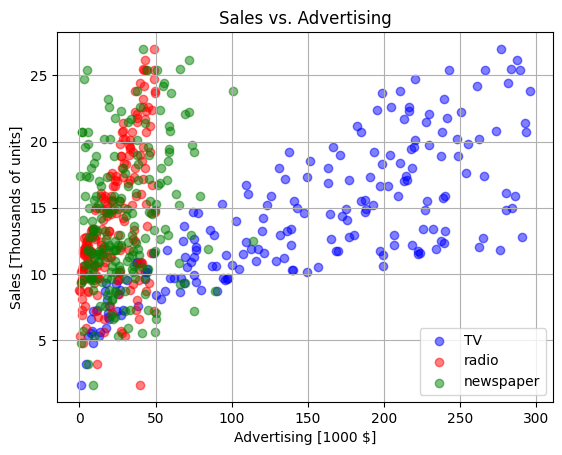

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv("Advertising.csv")
data.head()

plt.scatter(data.TV, data.sales, color='blue', label='TV', alpha=0.5)
plt.scatter(data.radio, data.sales, color='red', label='radio',alpha=0.5)
plt.scatter(data.newspaper, data.sales, color='green',
label='newspaper', alpha=0.5)
plt.legend(loc="lower right")
plt.title("Sales vs. Advertising")
plt.xlabel("Advertising [1000 $]")
plt.ylabel("Sales [Thousands of units]")
plt.grid()
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(data.drop('sales', axis=1), data.sales)

import pandas as pd
import statsmodels.formula.api as sm
ad = pd.read_csv("Advertising.csv")
model = sm.ols('sales ~ TV + radio + newspaper', ad).fit()
print(model.params)

data.corr()

Intercept    2.938889
TV           0.045765
radio        0.188530
newspaper   -0.001037
dtype: float64


,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.896   
Dependent Variable: sales            AIC:                780.3622
Date:               2023-05-31 23:47 BIC:                793.5555
No. Observations:   200              Log-Likelihood:     -386.18 
Df Model:           3                F-statistic:        570.3   
Df Residuals:       196              Prob (F-statistic): 1.58e-96
R-squared:          0.897            Scale:              2.8409  
------------------------------------------------------------------
                Coef.   Std.Err.     t     P>|t|    [0.025  0.975]
------------------------------------------------------------------
Intercept       2.9389    0.3119   9.4223  0.0000   2.3238  3.5540
TV              0.0458    0.0014  32.8086  0.0000   0.0430  0.0485
radio           0.1885    0.0086  21.8935  0.0000   0.1715  0.2055
newspaper      -0.0010    0.0059  -0.1767  0.8599  -0.0126  0.0105
--------------------

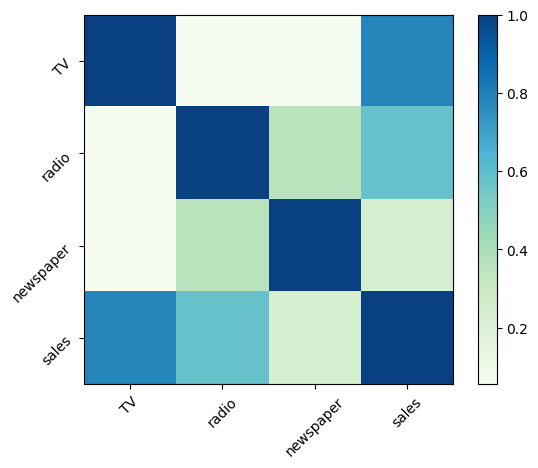

In [3]:
plt.imshow(ad.corr(), cmap=plt.cm.GnBu,
interpolation='nearest',data=True)
plt.colorbar()
tick_marks = [i for i in range(len(data.columns))]
plt.xticks(tick_marks, data.columns, rotation=45)
plt.yticks(tick_marks, data.columns, rotation=45)

print(model.summary2())

In [4]:
def evaluateModel(model):
  print("RSS = ", ((ad.sales - model.predict())**2).sum())
  print("R2 = ", model.rsquared)

# For TV
model_TV = sm.ols('sales ~ TV', data).fit()
print("model_TV")
evaluateModel(model_TV)
print("------------")
# For radio 
model_radio = sm.ols('sales ~ radio', data).fit()
print("model_radio")
evaluateModel(model_radio)
print("------------")
# For newspaper
model_newspaper = sm.ols('sales ~ newspaper', data).fit()
print("model_newspaper")
evaluateModel(model_newspaper)
print("------------")

# For TV & radio
model_TV_radio = sm.ols('sales ~ TV + radio', data).fit()
print("model_TV_radio")
evaluateModel(model_TV_radio)
print("------------")

# For TV & newspaper
model_TV_newspaper = sm.ols('sales ~ TV + newspaper', data).fit()
print("model_TV_newspaper")
evaluateModel(model_TV_newspaper)
print("------------")

# For TV, radio & newspaper
model_all = sm.ols('sales ~ TV + radio + newspaper', data).fit()
print("model_all")
evaluateModel(model_all)
print("------------")

model_TV
RSS =  2102.530583131351
R2 =  0.611875050850071
------------
model_radio
RSS =  3618.479549025087
R2 =  0.33203245544529547
------------
model_newspaper
RSS =  5134.804544111939
R2 =  0.05212044544430516
------------
model_TV_radio
RSS =  556.9139800676184
R2 =  0.8971942610828956
------------
model_TV_newspaper
RSS =  1918.5618118968277
R2 =  0.6458354938293271
------------
model_all
RSS =  556.8252629021872
R2 =  0.8972106381789522
------------


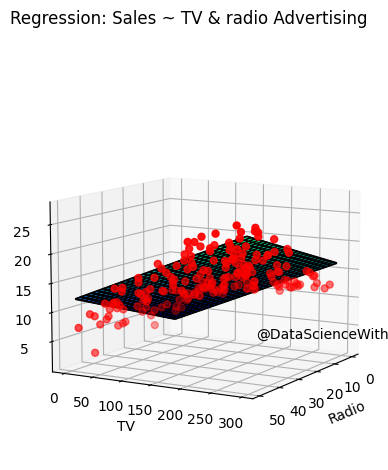

In [5]:
import numpy as np
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d import Axes3D

## Loading data in ad variable
ad = pd.read_csv("Advertising.csv")
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(211, projection='3d')
fig.suptitle('Regression: Sales ~ TV & radio Advertising')

# Defining z function (or sales in terms of TV and radio)
def z_function(x,y):
  return (2.938889 + (0.045765*y) + (0.188530*x))

X, Y = np.meshgrid(range(0,50,2),range(0,300,10))
Z = z_function(X, Y)

## Creating Wireframe
ax.plot_wireframe(X, Y, Z, color='black')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

## Creating Surface plot
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='winter',
edgecolor='black', alpha=0.8)

## Adding Scatter Plot
ax.scatter(ad.radio, ad.TV, ad.sales, c='red', s=25)

## Adding labels
ax.set_xlabel('Radio')
ax.set_ylabel('TV')
ax.set_zlabel('Sales')
ax.text(0,150,1, '@DataScienceWithSan')

## Rotating for better view
ax.view_init(10,30)

### **Remarks on the Results:**
1. A multiple linear regression model was used to analyze the relationship between advertising budgets and sales. The results showed that TV and radio budgets had a positive impact on sales, while newspaper budgets had either a negligible or negative effect.
2. A correlation analysis showed that there was a moderate relationship between newspaper and radio budgets. This suggests that an increase in the radio budget is often accompanied by higher spending on newspapers.
3. A hypothesis test was conducted to determine if at least one predictor (advertising medium) was valuable in predicting sales. The results of the test showed that at least one predictor was significant, indicating that the model was able to predict sales with some accuracy.
4. The process of feature selection was used to identify the most important predictors for the model. The results of the feature selection process showed that TV and radio budgets were the most important predictors, followed by newspaper budgets.
5. A 3D plot was created to visualize the relationship between TV, radio, and sales. The plot showed that the model was able to fit a regression plane to the data, providing a graphical representation of the relationship between the three variables.


In summary, the results of the study showed that TV and radio advertising were effective in increasing sales, while newspaper advertising was either ineffective or had a negative impact on sales. The study also showed that the combined effects of TV, radio, and newspaper advertising were greater than the sum of their individual effects.

# **TASK 02**
----------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
Mean Squared Error: 27.114957415580577


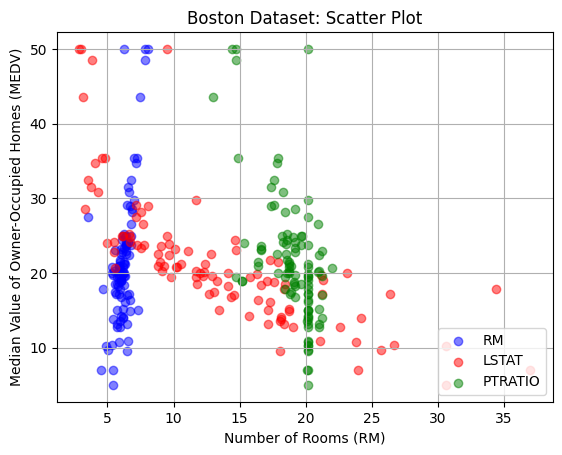

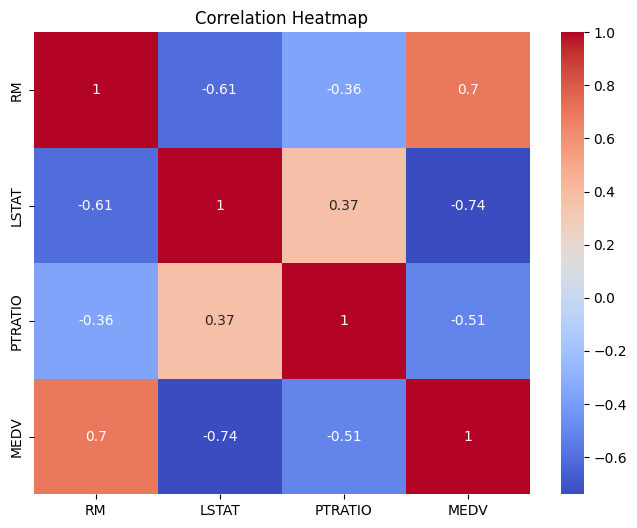

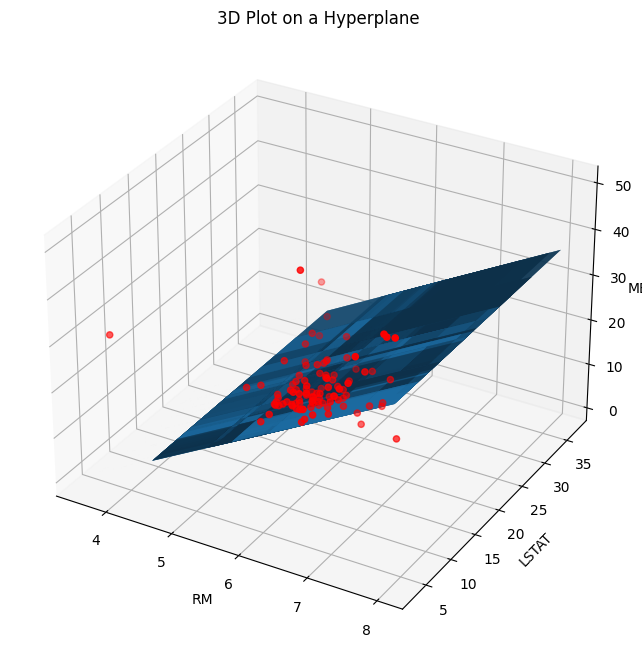

'\nThe above code implements Multiple Linear Regression (MLR) on the Boston dataset. It starts by loading the dataset and selecting the relevant features and target variable.The data is \nthen split into training and testing sets. A Linear Regression model is fitted on the training data, and predictions are made on the test data. The Mean Squared Error (MSE) is \ncalculated as an evaluation metric. The code also generates a 3D plot showing the test data points and fits a hyperplane to them. The hyperplane represents the predicted values of the\ntarget variable based on the input features. This allows for visualizing the relationship between the features and the target in a 3D space.\n'

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

boston_df = pd.read_csv('boston.csv')
boston_df.head()

boston_df.info()

boston_df.describe()

X = boston_df[['RM', 'LSTAT', 'PTRATIO']]  # Selecting 'RM', 'LSTAT', 'PTRATIO' as features
y = boston_df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

plt.scatter(X_test['RM'], y_test, color='blue', label='RM', alpha=0.5)
plt.scatter(X_test['LSTAT'], y_test, color='red', label='LSTAT', alpha=0.5)
plt.scatter(X_test['PTRATIO'], y_test, color='green', label='PTRATIO', alpha=0.5)
plt.legend(loc="lower right")
plt.title("Boston Dataset: Scatter Plot")
plt.xlabel("Number of Rooms (RM)")
plt.ylabel("Median Value of Owner-Occupied Homes (MEDV)")
plt.grid()
plt.show()

correlation_matrix = boston_df[['RM', 'LSTAT', 'PTRATIO', 'MEDV']].corr().round(2)
plt.figure(figsize=(8, 6))
sns.heatmap(data=correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = X_test['RM'].values.flatten()
y = X_test['LSTAT'].values.flatten()
z = y_test.values.flatten()

ax.scatter(x, y, z, c='r', marker='o')

# Fit a plane to the data points
plane_model = np.polyfit(x, z, deg=1)
plane = np.poly1d(plane_model)

# Create a meshgrid for the hyperplane surface
x_surface, y_surface = np.meshgrid(x, y)
z_surface = plane(x_surface)

ax.plot_surface(x_surface, y_surface, z_surface, alpha=0.5)

ax.set_xlabel("RM")
ax.set_ylabel("LSTAT")
ax.set_zlabel("MEDV")
plt.title('3D Plot on a Hyperplane')

plt.show()

"""
The above code implements Multiple Linear Regression (MLR) on the Boston dataset. It starts by loading the dataset and selecting the relevant features and target variable.The data is 
then split into training and testing sets. A Linear Regression model is fitted on the training data, and predictions are made on the test data. The Mean Squared Error (MSE) is 
calculated as an evaluation metric. The code also generates a 3D plot showing the test data points and fits a hyperplane to them. The hyperplane represents the predicted values of the
target variable based on the input features. This allows for visualizing the relationship between the features and the target in a 3D space.
"""



In [7]:
import pandas as pd

# Load the Boston Housing Dataset
boston = pd.read_csv('boston.csv')

# Create a Pandas DataFrame from the dataset
df = pd.DataFrame(boston)
df['PRICE'] = boston.MEDV  # Add the target variable (housing price) to the DataFrame

# Select the three features for multiple linear regression
features = ['RM', 'LSTAT', 'PTRATIO']
X = df[features]
y = df['PRICE']

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression

# Create an instance of the LinearRegression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

LinearRegression()

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate the mean squared error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate the coefficient of determination (R^2 score)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print('Mean Squared Error (MSE):', mse)
print('Coefficient of Determination (R^2 Score):', r2)

Mean Squared Error (MSE): 27.114957415580577
Coefficient of Determination (R^2 Score): 0.6302528487272827


In [11]:
# Get the coefficients and intercept of the linear regression model
coefficients = model.coef_
intercept = model.intercept_

# Print the coefficients and intercept
print('Intercept:', intercept)
print('Coefficients:', coefficients)

Intercept: 14.58809926157104
Coefficients: [ 4.93311836 -0.56712588 -0.86709475]


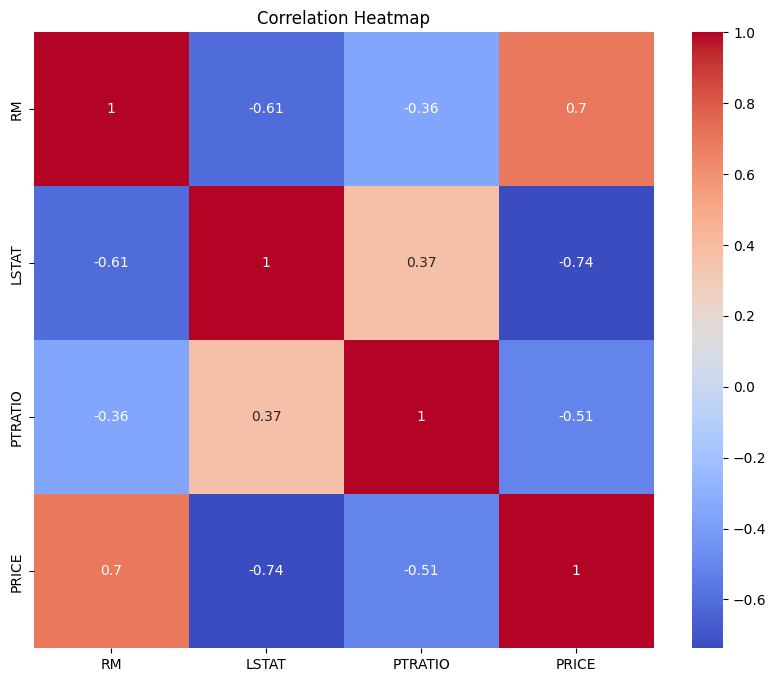

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = df[features + ['PRICE']].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

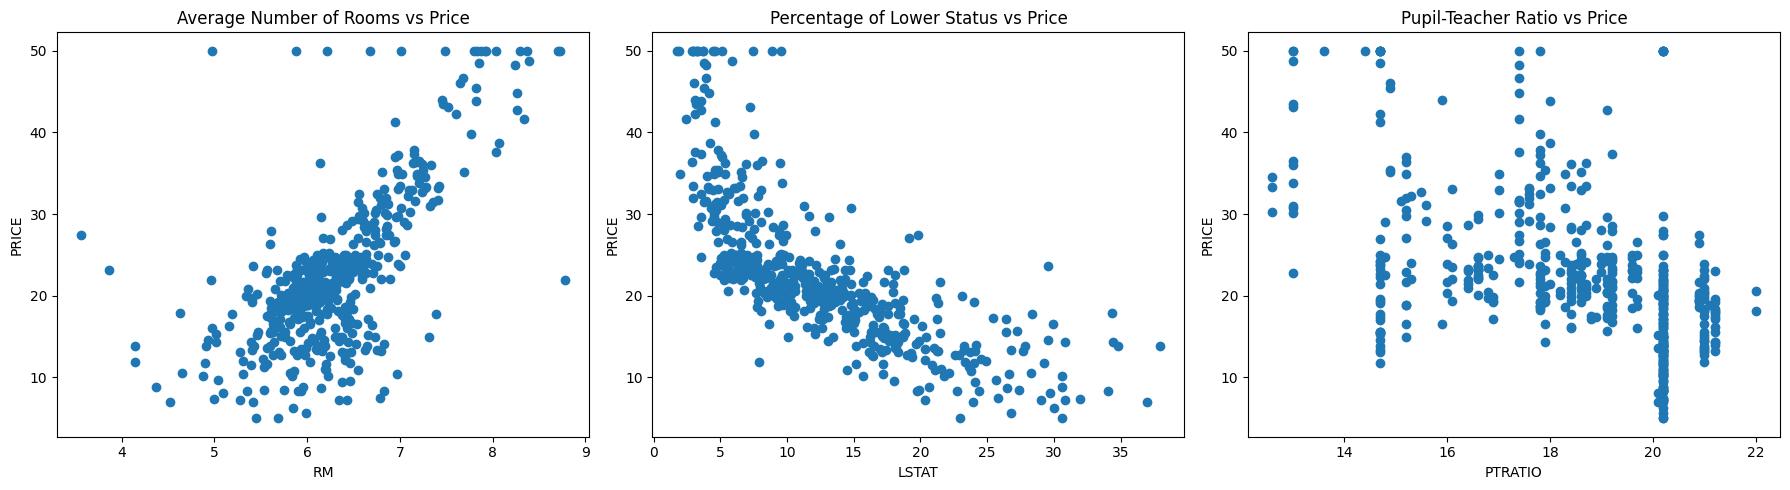

In [13]:
# Create scatter plots
plt.figure(figsize=(18, 5))

# RM - Average number of rooms per dwelling
plt.subplot(1, 3, 1)
plt.scatter(df['RM'], df['PRICE'])
plt.xlabel('RM')
plt.ylabel('PRICE')
plt.title('Average Number of Rooms vs Price')

# LSTAT - Percentage of lower status of the population
plt.subplot(1, 3, 2)
plt.scatter(df['LSTAT'], df['PRICE'])
plt.xlabel('LSTAT')
plt.ylabel('PRICE')
plt.title('Percentage of Lower Status vs Price')

# PTRATIO - Pupil-teacher ratio by town
plt.subplot(1, 3, 3)
plt.scatter(df['PTRATIO'], df['PRICE'])
plt.xlabel('PTRATIO')
plt.ylabel('PRICE')
plt.title('Pupil-Teacher Ratio vs Price')

plt.tight_layout()
plt.show()